# Overview of this notebook

This notebook demonstrates the process of reproducing the experiments described in the accompanying our paper. The paper proposes a method called MIAO (Mutual Impact Analysis of OSS) to quantify the competitive relationships between OSS projects and predict their survival.

- Detect analysis periods (Tm) with `miao.auto_detect_tms`
- Prepare VAR inputs (ADF, fractional differencing, lag selection + whiteness test)
- Estimate SVAR and compute IRFs
- Compute MIAO scores (MS_ij -> AMS_ij) across period shifts
- Train and evaluate decision trees to classify REV vs. non-REV

Key I/O:
- Inputs: `datasets/original/{daily,monthly}`, `dataset.yml`
- Outputs: `datasets/preprocessed/`, `adf_test_results/`, `var_estimation_results/`, `miao_score_tables/`, `datasets/decisiontree/`, and counterparts under `prediction/`

## Reproducible Environment

Environment: see `requirements.txt`

* OS: maxOS Sequoia 15.1 (24B2082)
* Chip: Apple M4 Max
* RAM: 64GB


In [1]:
# If you haven't installed the following packages, you need to install them first
# !pip install -r requirements.txt

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from typing import List, Dict
import warnings
import copy
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import graphviz
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier
from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning
from statsmodels.tsa.vector_ar.svar_model import SVAR
from statsmodels.stats.contingency_tables import mcnemar
from scipy import stats

from miao import parse_miao_db_yml, auto_detect_tms, create_Tms, \
    prepare_var, miao_phase1_with_period_shifts, miao_phase2_with_period_shifts, \
    get_unique_idx, create_decision_tree_df, competitors_sorted_by_lifetime_duplication, AutoDetectTmsError

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=ValueWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Preparation

- Load dataset.yml and identify competitors to be used in the experiment
  - Among those listed in README, competitors with larger temporal overlap are prioritized
- Sort the identified competitors by the number of commits in descending order

In [4]:
activity_time_series_dataset_path = f"./datasets/original/daily"
monthly_activity_time_series_dataset_path = f"./datasets/original/monthly"

db_original = parse_miao_db_yml("./dataset.yml")
daily_commits = {}

for db_ in db_original:
    repos = [c["name"] for c in db_["competitors"]] + [db_["name"]]
    for name in repos:
        A = pd.read_csv(f"./datasets/original/daily/{name}.csv", index_col=0)
        A.index = [pd.Timestamp(idx) for idx in A.index]
        daily_commits[name] = A

for db_ in db_original:
    # Sort competitors with longer period overlap first
    comps = competitors_sorted_by_lifetime_duplication(db_, daily_commits)
    comps1 = list(filter(lambda x: True if "in_readme" in x else False, comps)) # Listed in README
    comps2 = list(filter(lambda x: True if "in_readme" not in x else False, comps)) # Manually curated

    for c in (comps1 + comps2):
        commits = daily_commits[c["name"]]
        
        if "appearance_time" in c:
            commits = commits[c["appearance_time"]:]

        c["__n_commits__"] = len(commits)

    # Prioritize those listed in README
    comps = comps1[0:2]
    # If there are less than 2 items, i.e., only one listed in README, use manually curated ones as competitors
    if len(comps) < 2:
        comps += comps2[0:(2 - len(comps))]

    # Sort competitors by number of commits in descending order
    db_["competitors"] = list(sorted(comps, key=lambda x: x['__n_commits__'], reverse=True))
    assert(len(db_["competitors"]) == 2)

# Auto detecting $T_m$

The `miao.auto_detect_tms` function automatically detects the "start_date" and "end_date" for each OSS project's analysis. Based on settings of experiment, the maximum analysis period is 4 years, and if the period exceeds this, it will be divided into segments. However, if the last segment is less than 4 years, the analysis start date is set to 4 years before the end date.

For example, if the last period segment is from 2021-01-01 to 2023-01-01, since this is only a 2-year period, the analysis period will be adjusted to span from 2019-01-01 to 2023-01-01.

Note that since projects with analysis periods of less than 4 years are also included in the analysis targets, there exist groups whose analysis periods are not necessarily 4 years.

In [5]:
target_group = db_original[0] # group 1

tms = auto_detect_tms(
    target_group,
    limit_y=4,
    daily_dataset_path=activity_time_series_dataset_path,
    monthly_dataset_path=monthly_activity_time_series_dataset_path
)

T = create_Tms(tms[0]["start"], tms[0]["end"], 12, split_interval=False)
T

[[Timestamp('2016-09-25 00:00:00'), Timestamp('2017-09-24 00:00:00')],
 [Timestamp('2016-09-25 00:00:00'), Timestamp('2018-09-24 00:00:00')],
 [Timestamp('2016-09-25 00:00:00'), Timestamp('2019-09-24 00:00:00')],
 [Timestamp('2016-09-25 00:00:00'), Timestamp('2020-09-24 00:00:00')]]

### Verification of Temporal Overlap and Dataset Refinement

auto_detect_tms also has the secondary effect of selecting only those with temporal overlap of 1 year or more. This results in a sample size of 187.

In [6]:
def get_name(db):
    name = ",".join([db["name"]] + [c["name"] for c in db["competitors"]])
    return name

group_for_removes = []

for db_ in db_original:
    try:
        auto_detect_tms(
            db_,
            limit_y=4,
            daily_dataset_path=activity_time_series_dataset_path,
            monthly_dataset_path=monthly_activity_time_series_dataset_path
        )
    except AutoDetectTmsError as e:
        group_for_removes.append(get_name(db_))
    except Exception as e:
        raise e

db = list(filter(lambda x: get_name(x) not in group_for_removes, db_original))
print("N groups:", len(db))
print("REV class:", len(list(filter(lambda item: item["rev"] == True, db))))
print("Non-REV class:", len(list(filter(lambda item: item["rev"] == False, db))))

N groups: 187
REV class: 87
Non-REV class: 100


# Preparation for VAR Analysis


The `miao.prepare_var` function corresponds to PREPARE_VAR in the algorithm presented in the paper. prepare_var performs the following processes and returns input variables for VAR with optimal lag and preprocessed $A_i$:

* Extract subsequence $A_{T_m}$ from $A = [A_1, A_2, A_3]$ corresponding to $T_m$
* Conduct ADF test on $A_{T_m}$
* Apply fractional differencing if $A_{T_m}$ has unit root
* Search for lag between 1 and 15 that has Ljung-Box test $p \geq 0.1$ and minimum AIC (if none exists, select the * one with minimum AIC)

In [7]:
variable_order = [c["name"] for c in target_group["competitors"]] + [target_group["name"]]
As = []

for repo in variable_order:
    A = pd.read_csv(f"./datasets/original/daily/{repo}.csv", index_col=0)
    As.append((repo, A))
    
X_each_tm = prepare_var(T, As, maxlag=15)
assert(len(X_each_tm) == len(T))

Failed to reject the H0 of whiteness test: pvalue=0.931652810352918, lag=13, adf_p=0.004, 0.000, 0.045
Failed to reject the H0 of whiteness test: pvalue=0.4678785291128988, lag=14, adf_p=0.024, 0.000, 0.032
Failed to reject the H0 of whiteness test: pvalue=0.5751940222212749, lag=15, adf_p=0.010, 0.000, 0.002
Rejected the H0 of whiteness test: pvalue=0.0005506010203132108, lag=15, adf_p=0.001, 0.000, 0.037


`X_each_tm` stores input variables (represented as $\mathcal{D}'$ in the paper) to VAR from T1 up to a maximum of T4.

In [8]:
T1_lag, T1_X = X_each_tm[0]
T2_lag, T2_X = X_each_tm[1]
T3_lag, T3_X = X_each_tm[2]
T4_lag, T4_X = X_each_tm[3]

display(T1_X)
display(T2_X)
display(T3_X)
display(T4_X)

,tensorflow/tensorflow,pytorch/pytorch,chainer/chainer
2016-09-25,5,7,7
2016-09-26,49,8,21
2016-09-27,68,16,14
2016-09-28,47,5,8
2016-09-29,69,13,11
...,...,...,...
2017-09-20,55,29,11
2017-09-21,40,30,14
2017-09-22,57,21,3
2017-09-23,15,9,2


,tensorflow/tensorflow,pytorch/pytorch,chainer/chainer
2016-09-25,5,7,7.000000
2016-09-26,49,8,20.300000
2016-09-27,68,16,11.585000
2016-09-28,47,5,5.455500
2016-09-29,69,13,8.826862
...,...,...,...
2018-09-20,65,21,41.296128
2018-09-21,76,27,22.420236
2018-09-22,36,6,0.658577
2018-09-23,13,2,3.667551


,tensorflow/tensorflow,pytorch/pytorch,chainer/chainer
2016-09-25,5,7,7
2016-09-26,49,8,21
2016-09-27,68,16,14
2016-09-28,47,5,8
2016-09-29,69,13,11
...,...,...,...
2019-09-20,128,38,11
2019-09-21,32,22,3
2019-09-22,9,4,0
2019-09-23,76,24,2


,tensorflow/tensorflow,pytorch/pytorch,chainer/chainer
2016-09-25,5,7,7
2016-09-26,49,8,21
2016-09-27,68,16,14
2016-09-28,47,5,8
2016-09-29,69,13,11
...,...,...,...
2020-09-20,10,2,0
2020-09-21,85,20,0
2020-09-22,86,38,0
2020-09-23,105,40,0


The DataFrame generated by prepare_var is identical to the data output under the datasets/preprocessed directory.

In [9]:
T1_X.sum().sum() == pd.read_csv(f"./datasets/preprocessed/permute_0/original/T1/1_0.csv", index_col=0).sum().sum()

True

## Period shifts

In [10]:
target_repos = [c["name"] for c in target_group["competitors"]] + [target_group["name"]]
shifts = [pd.DateOffset(months=1), pd.DateOffset(months=2), pd.DateOffset(months=3)]

for shift in shifts:
    print(f"-------------- {shift.months} month(s) shift --------------")
    
    shifted_start = tms[0]["start"] + shift
    shifted_end = tms[0]["end"] + shift

    shifted_T = create_Tms(shifted_start, shifted_end, 12, split_interval=False)

    As = []

    for repo in target_repos:
        A = pd.read_csv(f"./datasets/original/daily/{repo}.csv", index_col=0)
        As.append((repo, A))

    X_each_tm = prepare_var(shifted_T, As, maxlag=15)
    assert(len(X_each_tm) == len(shifted_T))
    lag, X = X_each_tm[0]
    display(X)

-------------- 1 month(s) shift --------------
Failed to reject the H0 of whiteness test: pvalue=0.8976633386383727, lag=13, adf_p=0.002, 0.000, 0.000
Failed to reject the H0 of whiteness test: pvalue=0.46543551717215115, lag=14, adf_p=0.030, 0.000, 0.024
Failed to reject the H0 of whiteness test: pvalue=0.4978031733492466, lag=15, adf_p=0.015, 0.000, 0.002
Rejected the H0 of whiteness test: pvalue=0.0005268842965226518, lag=15, adf_p=0.002, 0.000, 0.046


,tensorflow/tensorflow,pytorch/pytorch,chainer/chainer
2016-10-25,69,7,23
2016-10-26,62,10,4
2016-10-27,67,8,25
2016-10-28,61,4,3
2016-10-29,16,5,1
...,...,...,...
2017-10-20,57,41,1
2017-10-21,11,2,3
2017-10-22,7,4,3
2017-10-23,44,10,25


-------------- 2 month(s) shift --------------
Failed to reject the H0 of whiteness test: pvalue=0.9833548403928332, lag=15, adf_p=0.000, 0.000, 0.037
Failed to reject the H0 of whiteness test: pvalue=0.4649973612612454, lag=15, adf_p=0.035, 0.000, 0.034
Failed to reject the H0 of whiteness test: pvalue=0.3649157028274071, lag=15, adf_p=0.009, 0.000, 0.004
Rejected the H0 of whiteness test: pvalue=0.0004527519471578316, lag=15, adf_p=0.001, 0.000, 0.038


,tensorflow/tensorflow,pytorch/pytorch,chainer/chainer
2016-11-25,13,1,15
2016-11-26,8,9,1
2016-11-27,4,0,11
2016-11-28,47,8,15
2016-11-29,59,39,10
...,...,...,...
2017-11-20,41,11,16
2017-11-21,51,17,13
2017-11-22,81,11,14
2017-11-23,26,6,5


-------------- 3 month(s) shift --------------
Failed to reject the H0 of whiteness test: pvalue=0.9468101179042655, lag=15, adf_p=0.001, 0.000, 0.001
Failed to reject the H0 of whiteness test: pvalue=0.685902881822655, lag=14, adf_p=0.026, 0.000, 0.026
Failed to reject the H0 of whiteness test: pvalue=0.33355319147851165, lag=15, adf_p=0.008, 0.000, 0.006
Rejected the H0 of whiteness test: pvalue=0.0002868782457577801, lag=15, adf_p=0.001, 0.000, 0.043


,tensorflow/tensorflow,pytorch/pytorch,chainer/chainer
2016-12-25,4,4,0
2016-12-26,3,4,5
2016-12-27,26,24,29
2016-12-28,25,17,5
2016-12-29,28,36,1
...,...,...,...
2017-12-20,110,22,37
2017-12-21,74,18,64
2017-12-22,63,14,29
2017-12-23,14,12,4


# SVAR

The following is code that reads CSV data corresponding to shift, Tm, and group from datasets/preprocessed and estimates SVAR. For lags, it uses the pre-estimated values recorded in var_estimation_result.csv.

In [11]:
shift = "original"
Tm = "T4"
group_with_sep = "1_0"
permute_id = 0

var_result = pd.read_csv(f"./var_estimation_results/aic/permute_{permute_id}.csv")
X = pd.read_csv(f"./datasets/preprocessed/permute_{permute_id}/{shift}/{Tm}/{group_with_sep}.csv", index_col=0)

# A matrix that represent recursive constraint. E will be estimated. 
A = np.array([
    [1, 0, 0],
    ["E", 1, 0],
    ["E", "E", 1]
])

cond = (var_result["group"] == group_with_sep) & (var_result["Tm"] == Tm) & (var_result["period_shift"] == shift)
lag = var_result[cond].iloc[0].lag 

model = SVAR(X, svar_type="A", A=A)
results = model.fit(maxlags=lag)

# IRF Calculation

The impulse response can be calculated using `irf = results.irf(period)`, and in the case of SVAR, the calculation results are stored in `irf.svar_irfs`. When the `irf.plot()` function is called, an n✕n figure is displayed. The shape of svar_irfs is a third-order tensor of dimensions (period, n, n).

In [12]:
# In our paper, period=200.
period = 20
irf = results.irf(period)

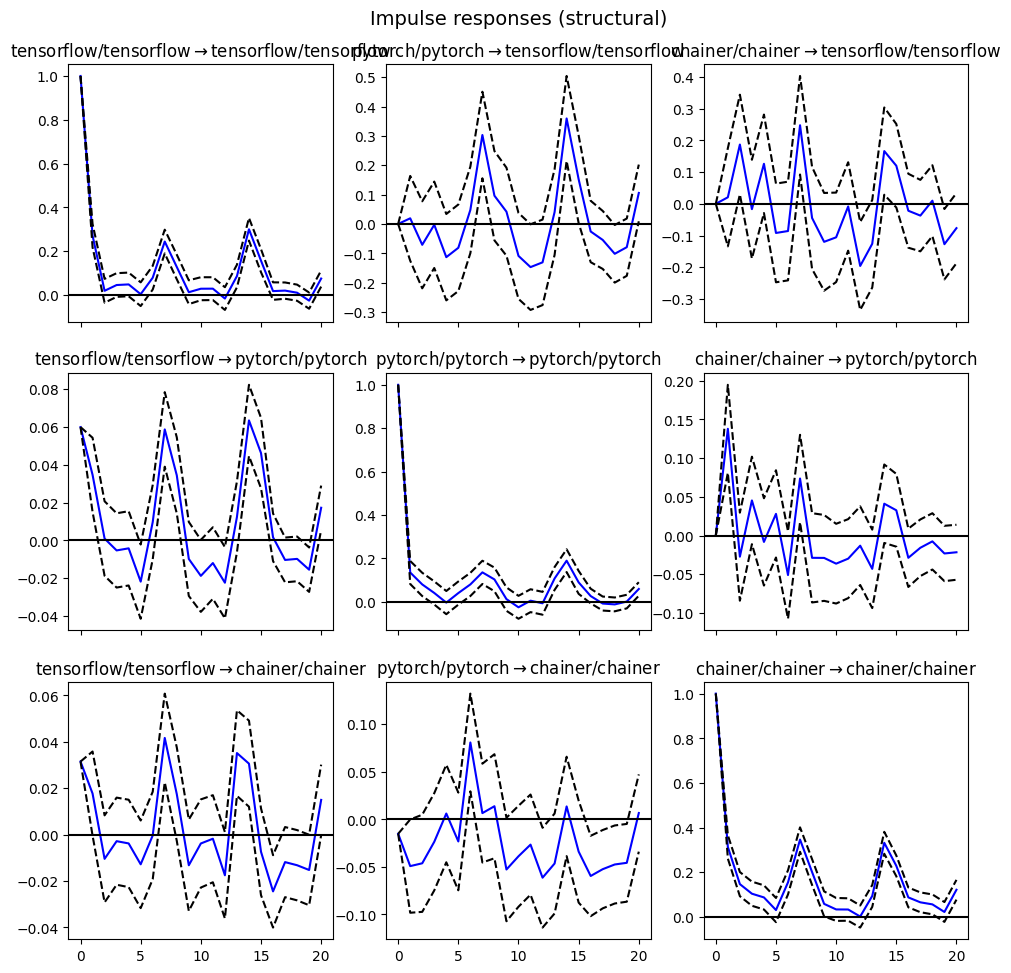

In [13]:
irf.plot();

## IRF Cum Effects

The cumulative impulse response can be obtained from `irf.svar_cum_effects`. The shape of it is same as svar_irfs. 

Similar to the regular IRF, you can plot the graph using `irf.plot_cum_effects()`. However, it is important to note that this graph shows the cumulative impulse responses based on the standard reduced-form VAR, not the SVAR-based impulse responses. Nevertheless, we will create this plot as an example to examine the shape of the cumulative impulse responses.

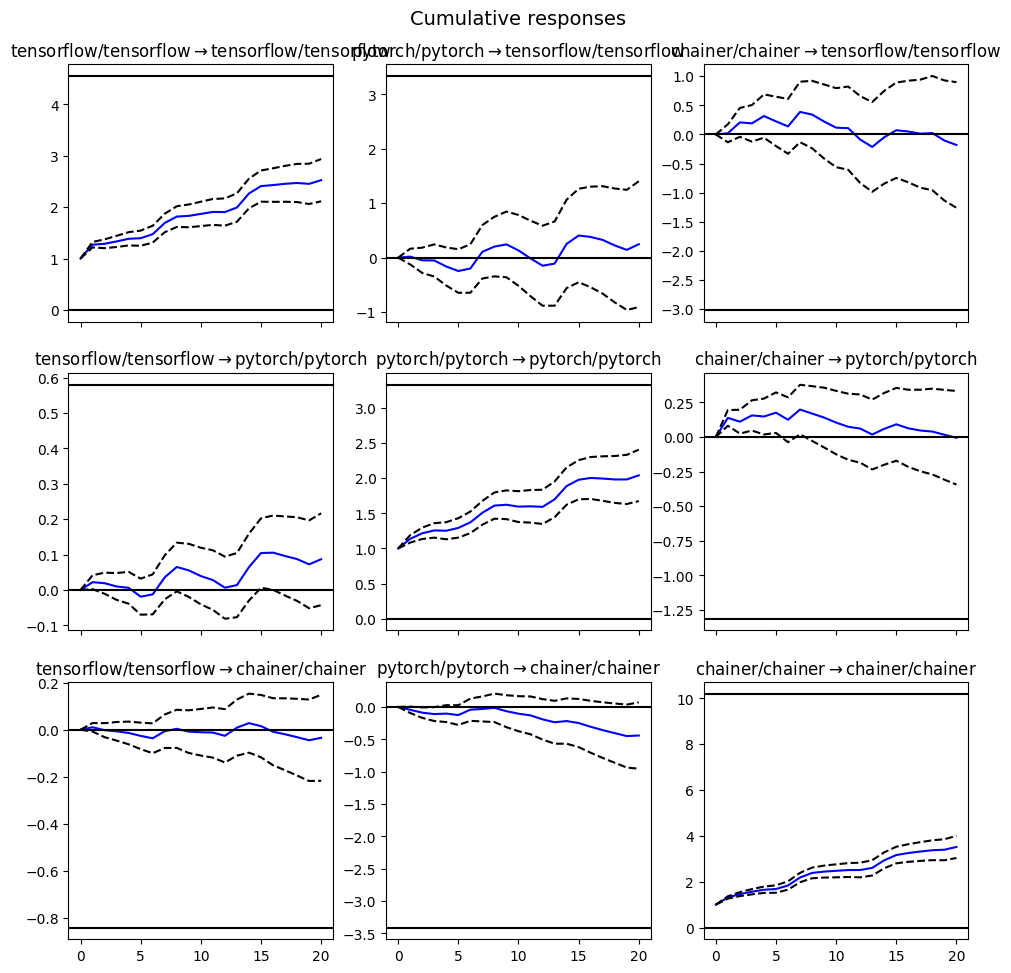

In [14]:
irf.plot_cum_effects();

In [15]:
irf.svar_cum_effects.shape

(21, 3, 3)

In [16]:
# svar_cum_effects of tensorflow -> tensorflow
irf.svar_cum_effects[:, 0, 0]

array([1.        , 1.27123162, 1.29044084, 1.3359519 , 1.38426577,
       1.38793141, 1.46681507, 1.71079756, 1.83877754, 1.85148512,
       1.88011186, 1.90904127, 1.89272398, 1.97920051, 2.27923666,
       2.43586867, 2.45364343, 2.47367659, 2.48410965, 2.45833086,
       2.53342766])

In [17]:
# svar_cum_effects of pytorch -> chainer
irf.svar_cum_effects[:, 2, 1]

array([-0.01521581, -0.06437632, -0.11058168, -0.1341924 , -0.12811645,
       -0.15136796, -0.0706511 , -0.06412835, -0.05038756, -0.10310254,
       -0.14192725, -0.16851903, -0.22984212, -0.27629661, -0.26275137,
       -0.29667363, -0.3562062 , -0.40860114, -0.45605312, -0.50175828,
       -0.49514433])

The last index of irf.svar_cum_effects corresponds to the SCE (Shock Cumulative Effect) between each pair of OSS.

In [18]:
irf.svar_cum_effects[-1]

array([[ 2.53342766,  0.2500328 , -0.18066741],
       [ 0.20894748,  2.04059254, -0.00570264],
       [ 0.0501106 , -0.49514433,  3.51934022]])

# MIAO Score Calculation

MIAO Score definition. 

$$
\mathrm{MS}_{ij} = (-1) \cdot \sum_{k=1}^m \mathrm{SCE}_{ji}^k
$$

In [19]:
shifts = ["original", "1_month_shifted", "2_month_shifted", "3_month_shifted"]
Tms = ["T1", "T2", "T3", "T4"]
group_with_sep = "1_0"
permutation_id = "0"

shift_summaries = miao_phase1_with_period_shifts(A, shifts, Tms, group_with_sep, permutation_id)

## MIAO Score Table

This result matches the corresponding csv results under the `miao_score_tables` directory

In [20]:
miao_score_table = miao_phase2_with_period_shifts(shift_summaries)
display(miao_score_table)

,AMS_ij,normalized_AMS_ij
pytorch/pytorch -> tensorflow/tensorflow,-4.442387,-5.802585
chainer/chainer -> tensorflow/tensorflow,-2.570788,5.356524
tensorflow/tensorflow -> pytorch/pytorch,-0.602913,-4.117443
chainer/chainer -> pytorch/pytorch,-0.650781,8.010384
tensorflow/tensorflow -> chainer/chainer,-0.217748,3.407640
pytorch/pytorch -> chainer/chainer,5.904570,16.930895


In [21]:
# For Example, miao_score_tables/1_0.csv matches above table.
pd.read_csv("./miao_score_tables/permute_0/1_0.csv", index_col=0)

,AMS_ij,normalized_AMS_ij
pytorch/pytorch -> tensorflow/tensorflow,-4.442387,-5.802585
chainer/chainer -> tensorflow/tensorflow,-2.570788,5.356524
tensorflow/tensorflow -> pytorch/pytorch,-0.602913,-4.117443
chainer/chainer -> pytorch/pytorch,-0.650781,8.010384
tensorflow/tensorflow -> chainer/chainer,-0.217748,3.407640
pytorch/pytorch -> chainer/chainer,5.904570,16.930895


In [22]:
# Entire miao score tables for EVAL2 are located in prediction dirctory.
pd.read_csv("./prediction/miao_score_tables/permute_0/1_0.csv", index_col=0)

,AMS_ij,normalized_AMS_ij
pytorch/pytorch -> tensorflow/tensorflow,-0.244122,-0.716689
chainer/chainer -> tensorflow/tensorflow,-2.531152,-2.723520
tensorflow/tensorflow -> pytorch/pytorch,0.245536,-0.902548
chainer/chainer -> pytorch/pytorch,-1.281584,-1.786170
tensorflow/tensorflow -> chainer/chainer,-0.396327,-1.271825
pytorch/pytorch -> chainer/chainer,1.146439,1.901330


# Decision Tree Analysis for EVAL1

Training and Performance Evaluation of Decision Tree Model Using datasets/decisiontree/{permute_i}.csv

In [23]:
def invoke_decision_tree_classifer_and_report(params, dfs):
    classifier_results_permutes = []
    
    cols = [
        'c2 -> t',
        'c1 -> t',
        'c1 -> c2',
        'c2 -> c1',
        't -> c1',
        't -> c2',    
    ]
    
    for i, decision_tree_df in enumerate(dfs):
        data = decision_tree_df
        X = data[cols]
        y = data['label']
        
        cv_scores = []
        y_preds = []
        
        loo = LeaveOneOut()
        
        for train_index, test_index in loo.split(X):
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
            clf = DecisionTreeClassifier(**params)
            clf.fit(X_train, y_train)
        
            y_pred = clf.predict(X_test)
            cv_scores.append(accuracy_score(y_test, y_pred))
            y_preds.append(y_pred[0])
        
        cv_scores = np.array(cv_scores)
        confidence_level = 0.95
        degrees_of_freedom = len(cv_scores) - 1
        sample_mean = np.mean(cv_scores)
        sample_standard_error = stats.sem(cv_scores)
        
        ci_low, ci_high = stats.t.interval(confidence_level, degrees_of_freedom, 
                                           loc=sample_mean, 
                                           scale=sample_standard_error)
    
        print(f"------ Classification Report; Set {i+1} ------ ")
        
        print(f"Sample size: {len(y)}")
        print(f"Mean accuracy: {cv_scores.mean():.4f}")
        print(f"Standard deviation of accuracy: {cv_scores.std():.4f}")
        print(f"95% confidence interval: ({ci_low:.4f}, {ci_high:.4f})")
        
        print("")
        print(classification_report(y, y_preds, target_names=["nonREV", "REV"]))
    
        classifier_results_permutes.append((y_preds, X, y))

    return classifier_results_permutes

## How to Construct Explanatory Variables for Decision Tree

By passing the MIAO score table to create_decision_tree_df, it can be converted into explanatory variables for the decision tree. When this is done for all groups, the data under datasets/decisiontree is generated.

In [24]:
miao_score_table.attrs = {
    "target": get_unique_idx(target_group),
    "group": 1,
    "n_Tm": int((tms[0]["end"] - tms[0]["start"]).days/365)
}

create_decision_tree_df(db, [miao_score_table], normalize=True, column="normalized_AMS_ij")

,label,group_id,split_id,group,target,c2 -> c1,t -> c1,c1 -> c2,t -> c2,c1 -> t,c2 -> t
0,1,1,0,1,"chainer,tensorflow,pytorch",-1.450646,1.339131,-1.029361,2.002596,0.85191,4.232724


## Report of Decision Tree Classifier

In [25]:
eval1_params = {
    'max_depth': 3,
    'min_samples_split': 20,
    'min_samples_leaf': 8,
    'class_weight': "balanced",
    'random_state': 42
}


eval1_decision_tree_df_permutes = [
    pd.read_csv("./datasets/decisiontree/normalized/permute_0.csv"),
    pd.read_csv("./datasets/decisiontree/normalized/permute_1.csv"),
    pd.read_csv("./datasets/decisiontree/normalized/permute_2.csv"),
    pd.read_csv("./datasets/decisiontree/normalized/permute_3.csv"),
    pd.read_csv("./datasets/decisiontree/normalized/permute_4.csv"),
    pd.read_csv("./datasets/decisiontree/normalized/permute_5.csv"),
]

eval1_classifier_results_permutes = invoke_decision_tree_classifer_and_report(eval1_params, eval1_decision_tree_df_permutes)

------ Classification Report; Set 1 ------ 
Sample size: 187
Mean accuracy: 0.8128
Standard deviation of accuracy: 0.3900
95% confidence interval: (0.7564, 0.8693)

              precision    recall  f1-score   support

      nonREV       0.80      0.87      0.83       100
         REV       0.83      0.75      0.79        87

    accuracy                           0.81       187
   macro avg       0.82      0.81      0.81       187
weighted avg       0.81      0.81      0.81       187

------ Classification Report; Set 2 ------ 
Sample size: 187
Mean accuracy: 0.7754
Standard deviation of accuracy: 0.4173
95% confidence interval: (0.7150, 0.8358)

              precision    recall  f1-score   support

      nonREV       0.80      0.78      0.79       100
         REV       0.75      0.77      0.76        87

    accuracy                           0.78       187
   macro avg       0.77      0.78      0.77       187
weighted avg       0.78      0.78      0.78       187

------ Classific

## Feature importance

In [26]:
y_preds, X, y = eval1_classifier_results_permutes[0]
eval1_clf = DecisionTreeClassifier(**eval1_params)
eval1_clf.fit(X, y)

export_graphviz(eval1_clf, feature_names=X.columns, class_names=["nonREV", "REV"], filled=True)
dot_data = export_graphviz(eval1_clf, feature_names=X.columns, class_names=["nonREV", "REV"], filled=True)
eval1_graph = graphviz.Source(dot_data)

feature_importance_df = pd.DataFrame({
    'feature_importance': eval1_clf.feature_importances_,
}, index=X.columns).sort_values(by='feature_importance', ascending=False)

feature_importance_df

,feature_importance
t -> c2,0.858462
t -> c1,0.112182
c1 -> c2,0.029357
c2 -> t,0.000000
c1 -> t,0.000000
c2 -> c1,0.000000


## Graph of decision tree

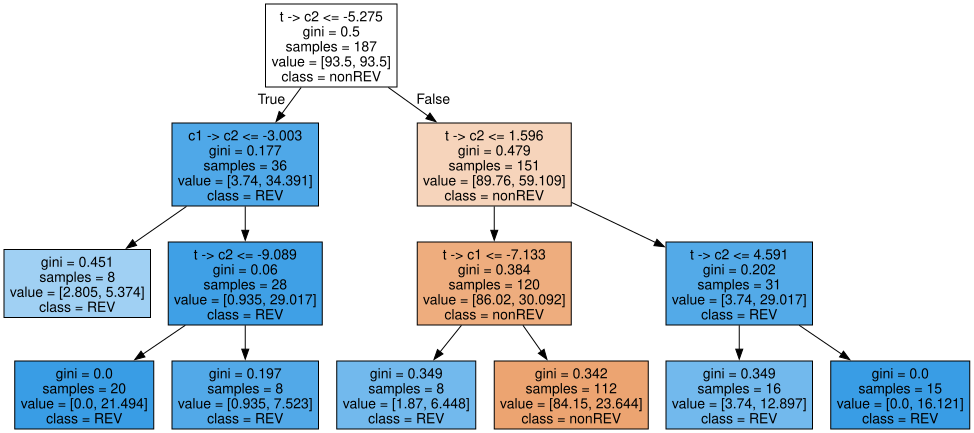

In [27]:
eval1_graph

# Decision Tree Analysis for EVAL2

In [28]:
eval2_params = {
    'max_depth': 3,
    'min_samples_split': 21,
    'min_samples_leaf': 7,
    'class_weight': "balanced",
    'random_state': 42
}

eval2_decision_tree_df_permutes = [
    pd.read_csv("./prediction/datasets/decisiontree/normalized/permute_0.csv"),
    pd.read_csv("./prediction/datasets/decisiontree/normalized/permute_1.csv"),
    pd.read_csv("./prediction/datasets/decisiontree/normalized/permute_2.csv"),
    pd.read_csv("./prediction/datasets/decisiontree/normalized/permute_3.csv"),
    pd.read_csv("./prediction/datasets/decisiontree/normalized/permute_4.csv"),
    pd.read_csv("./prediction/datasets/decisiontree/normalized/permute_5.csv"),
]

eval2_classifier_results_permutes = invoke_decision_tree_classifer_and_report(eval2_params, eval2_decision_tree_df_permutes)

------ Classification Report; Set 1 ------ 
Sample size: 159
Mean accuracy: 0.7736
Standard deviation of accuracy: 0.4185
95% confidence interval: (0.7078, 0.8393)

              precision    recall  f1-score   support

      nonREV       0.80      0.86      0.83       100
         REV       0.73      0.63      0.67        59

    accuracy                           0.77       159
   macro avg       0.76      0.74      0.75       159
weighted avg       0.77      0.77      0.77       159

------ Classification Report; Set 2 ------ 
Sample size: 159
Mean accuracy: 0.7610
Standard deviation of accuracy: 0.4265
95% confidence interval: (0.6940, 0.8280)

              precision    recall  f1-score   support

      nonREV       0.80      0.83      0.81       100
         REV       0.69      0.64      0.67        59

    accuracy                           0.76       159
   macro avg       0.74      0.74      0.74       159
weighted avg       0.76      0.76      0.76       159

------ Classific

## Feature importance

In [29]:
y_preds, X, y = eval2_classifier_results_permutes[3]
eval2_clf = DecisionTreeClassifier(**eval2_params)
eval2_clf.fit(X, y)

export_graphviz(eval2_clf, feature_names=X.columns, class_names=["nonREV", "REV"], filled=True)
dot_data = export_graphviz(eval2_clf, feature_names=X.columns, class_names=["nonREV", "REV"], filled=True)
eval2_graph = graphviz.Source(dot_data)

feature_importance_df = pd.DataFrame({
    'feature_importance': eval2_clf.feature_importances_,
}, index=X.columns).sort_values(by='feature_importance', ascending=False)

feature_importance_df

,feature_importance
c2 -> t,0.900025
c1 -> t,0.099975
c1 -> c2,0.000000
c2 -> c1,0.000000
t -> c1,0.000000
t -> c2,0.000000


## Graph of decision tree

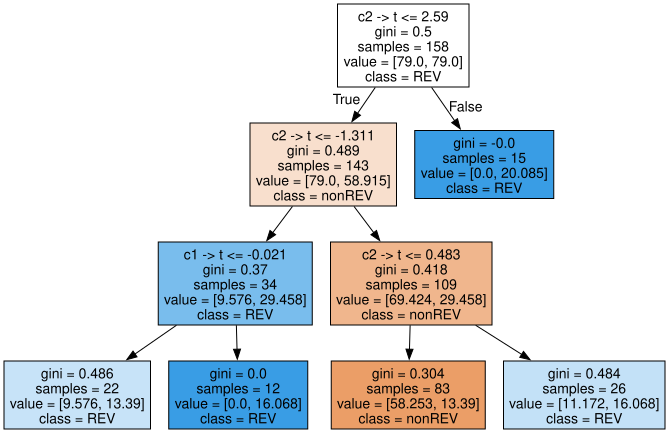

In [30]:
eval2_graph